Species Tree...
(((((8:0.20887949246167967,9:0.20887949246167967)7:0.03780195872976483,6:0.2466814511914445)4:0.21143042126448255,5:0.45811187245592705)2:0.4745714046104497,3:0.9326832770663768)1:0.06731672293362323)0:0.0;


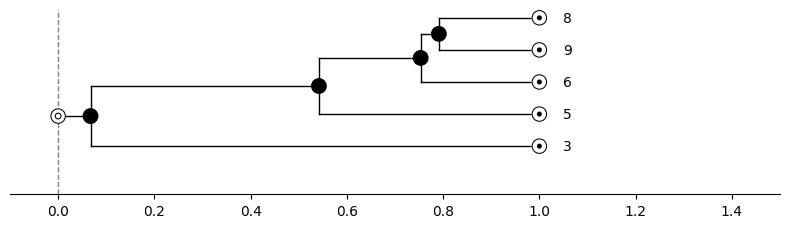

In [38]:
import asymmetree.treeevolve as te
from asymmetree.utils.phylogenetic_trees import to_newick
from asymmetree.visualization.tree_vis import visualize
from asymmetree.seqevolve import Evolver, SubstModel

# 1. Generate species tree
n_species = 5
tree_age = 1.0
birth_rate = 1.0
S = te.species_tree_n_age(n_species, tree_age, birth_rate=birth_rate)

print("Species Tree...")
print(to_newick(S))
visualize(S, save_as="yule_tree.pdf")


Gene Tree...
((((((10<7-9>:0.12775208242586514,11<9>:0.15521835398259642)9:0.05366113847908324,8<8>:0.20887949246167967)6:0.03780195872976483,7<6>:0.2466814511914445)4:0.21143042126448255,5<5>:0.45811187245592705)2:0.4745714046104497,3<3>:0.9326832770663768)1:0.06731672293362323)0:0.0;


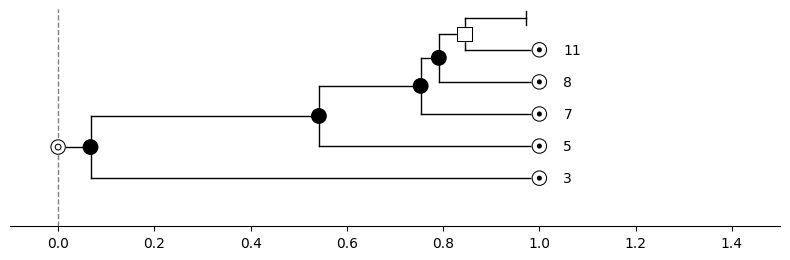

In [39]:
# 2. Simulate gene family
dupl_rate = 1.0
loss_rate = 1.0
hgt_rate = 0.2
gc_rate = 0.2
prohibit = "per_species"
gene_tree = te.dated_gene_tree(
    S,
    dupl_rate=dupl_rate,
    loss_rate=loss_rate,
    hgt_rate=hgt_rate,
    gc_rate=gc_rate,
    prohibit_extinction=prohibit
)

print("Gene Tree...")
print(to_newick(gene_tree, reconc=True))
visualize(gene_tree, save_as="yule_tree.pdf")

In [40]:
# 3. Inspect events
# 3. Inspect events (versión robusta)
event_counts = {'S': 0, 'D': 0, 'L': 0, 'T': 0, 'GC': 0}

# Intentar obtener iterador de nodos
if hasattr(gene_tree, 'nodes'):
    nodes_iter = gene_tree.nodes()
elif hasattr(gene_tree, 'traverse'):
    nodes_iter = gene_tree.traverse()
elif hasattr(gene_tree, 'iter_nodes'):
    nodes_iter = gene_tree.iter_nodes()
else:
    # Recorrido manual desde la raíz
    def get_all_nodes(node):
        nodes = [node]
        for child in node.children:
            nodes.extend(get_all_nodes(child))
        return nodes
    nodes_iter = get_all_nodes(gene_tree.root)

for node in nodes_iter:
    if hasattr(node, 'event'):
        event = node.event
        if event in event_counts:
            event_counts[event] += 1

print("Event summary...")
print(f"Speciations (S): {event_counts['S']}")
print(f"Duplications (D): {event_counts['D']}")
print(f"Losses (L): {event_counts['L']}")
print(f"Transfers (T): {event_counts['T']}")
print(f"Conversions (GC): {event_counts['GC']}")

Event summary...
Speciations (S): 9
Duplications (D): 1
Losses (L): 1
Transfers (T): 0
Conversions (GC): 0


In [ ]:
# ================================================================
# 4. SIMULATE NUCLEOTIDE SEQUENCES (with mutations)
# ================================================================

print("\n--- Simulating nucleotide sequences along the gene tree ---")

# Model for the mutations in the sequence (JC69, K80 o GTR)
subst_model = SubstModel('n', 'JC69')   # 'n' = nucleótidos

# Create the evolver for the nucleotide sequences
evolver = Evolver(subst_model)

evolver.evolve_along_tree(gene_tree, start_length=150)

# First sequences as example
print("\nFirst 3 sequences (first 60 bp):")
count = 0
for leaf in gene_tree.leaves():
    if count < 6:
        seq_array = evolver.sequences[leaf]
        seq_str = subst_model.to_sequence(seq_array)
        species_label = leaf.species.label if hasattr(leaf, 'species') else 'unknown'
        print(f">Gene_{leaf.label}_species_{species_label}")
        print(seq_str[:60] + "...")
        count += 1



--- Simulating nucleotide sequences along the gene tree ---

First 3 sequences (first 60 bp):
>Gene_10_species_unknown
GCTCAAGACTCACTAACTCCATCTGTAATGCTTGGCGGGCGAAGTAACTCTGGCCTACGC...
>Gene_11_species_unknown
GGTCAAGACCCACCGCCTCCAGCTGTAATGCGTTGGGGGCGATCTAACTGTTGCCACAAC...
>Gene_8_species_unknown
ACTGAAGACCCACCAGCTCGACCTCTCATGCGTTGGGAAAGACCTATCGCCCGCGACAAC...
>Gene_7_species_unknown
GCTGACGACATATCACCTAGAGCGCTCATGCGTGGCGAAAGAACTAACTCTTTCGACAAT...
>Gene_5_species_unknown
TCTTAACACGCACGATCAATTGGCAACACCCGTTGATTTCGATGTTAACCTCTCTACCAA...
>Gene_3_species_unknown
TGTTAGAATATATCCGGTAAACGATTTCAGCGAAGTTAGCGGTGGCGCTCTACTCAATGT...
